# 📉 The Mathematics of Saturation & Diminishing Returns

> **A math-first tour of how `mmm_framework` represents the *diminishing returns* of marketing.**
> This is notebook **02** in the math series. We derive each curve, plot it, and verify every formula
> against the **actual framework code** with `assert` statements — so "the notebook runs clean" *means*
> "the math is right."

Adstock (notebook 01) answered *when* spend acts. Saturation answers *how much each additional dollar
buys*. The first \$10k of search spend captures the high-intent shoppers; the next \$10k reaches people
who were going to convert anyway, or no one at all. Formally: the **response is a nonlinear, increasing,
concave-or-S-shaped function of (adstocked) spend**, and its **slope — the value of the next dollar — falls
as spend rises.** That falling slope is the whole point: it is what makes a finite optimal budget exist.

The framework ships **two** saturation families, and they have *different shapes* — getting that
distinction right is the spine of this notebook:

| | Form | Equation | Shape on $x\ge 0$ | Where in the framework |
|---|---|---|---|---|
| **Core** | logistic / "exponential" | $f(x)=1-e^{-\lambda x}$ | strictly **concave** (no S) | `transforms.logistic_saturation`; used by default `BayesianMMM` |
| **Alternative** | **Hill** | $f(x)=\dfrac{x^{n}}{x^{n}+\kappa^{n}}$ | $n=1$ hyperbolic · $n>1$ **S-shaped** | PyMC / `mmm_extensions` path |

⚠️ **A naming trap we will correct head-on.** The framework's docstring calls $1-e^{-\lambda x}$
"S-shaped." It is **not** — on $x\ge0$ it is strictly *concave* with its steepest slope at the origin and
**no inflection point**. The genuine S (slow start, then acceleration, then a ceiling) belongs only to the
**Hill curve with $n>1$**. We make this concrete and assert it.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from aurora import PALETTE, CHANNEL_COLORS   # brand colors for visual consistency
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

We pull the real transform straight from the framework — every plot and assertion involving the core
curve calls this exact function, not a re-implementation. Hill is *not* shipped in `transforms` (it lives
in the PyMC extension path), so we implement it inline in NumPy purely for illustration and contrast.

In [2]:
from mmm_framework.transforms import logistic_saturation, geometric_adstock

# A dense nonnegative spend grid (think: normalized, adstocked spend in [0, ~3]).
x = np.linspace(0.0, 3.0, 600)
LAMS = [0.5, 1.0, 2.0, 4.0]                       # saturation rates to sweep
CH = list(CHANNEL_COLORS)                          # ['TV','Search','Social','Display']
print("loaded:", logistic_saturation.__name__, "| channels:", CH)
print("sanity:", logistic_saturation(np.array([0., .5, 1., 2., 5.]), 1.0).round(3))

loaded: logistic_saturation | channels: ['TV', 'Search', 'Social', 'Display']
sanity: [0.    0.393 0.632 0.865 0.993]


## 1. The core curve: $f(x) = 1 - e^{-\lambda x}$

This is what the **default `BayesianMMM` actually uses** (`model/base.py` lines 946–948):

```python
sat_lam   = pm.Exponential(f"sat_lam_{channel}", lam=0.5)     # rate prior, mean = 2
exponent  = pt.clip(-sat_lam * x_adstocked, -20, 0)           # numerical clamp
x_saturated = 1 - pt.exp(exponent)                            # == 1 - exp(-sat_lam * x_adstocked)
```

So the curve acts on the **adstocked** spend, and the single parameter $\lambda$ ($= $`sat_lam`) is given
an $\mathrm{Exponential}(0.5)$ prior (mean $2$). The `pt.clip(..., -20, 0)` only guards `exp` from
underflow at huge spend; mathematically the function is

$$
f(x) \;=\; 1 - e^{-\lambda x}, \qquad x \ge 0 \;\; (\text{negatives clipped to } 0), \qquad \lambda > 0.
$$

### Properties, derived

**Anchored at the origin.** $f(0) = 1 - e^{0} = 0$. No spend, no response.

**Bounded above by 1 (never reached).** Since $e^{-\lambda x} > 0$ for all finite $x$, we have
$f(x) < 1$ strictly, and $f(x)\to 1$ as $x\to\infty$. The range is $[0, 1)$. This is the *ceiling*: an
intrinsic maximum effect the channel can deliver no matter how much you spend.

**Strictly increasing and strictly concave** (this is the corrected shape claim). Differentiate:

$$
f'(x) \;=\; \lambda\, e^{-\lambda x} \;>\; 0,
\qquad
f''(x) \;=\; -\lambda^{2}\, e^{-\lambda x} \;<\; 0
\quad\text{for all } x\ge 0.
$$

Because $f''<0$ *everywhere* on $x\ge 0$, the curve has **no inflection point** — it is the classic
diminishing-returns silhouette, not a sigmoid. (Algebraically $1-e^{-\lambda x}$ is the CDF of an
$\mathrm{Exponential}(\lambda)$ random variable; an exponential CDF is concave, unlike the S-shaped
normal/logistic CDFs.)

**Half-saturation point.** Solve $f(x_{1/2}) = \tfrac12$:

$$
1 - e^{-\lambda x_{1/2}} = \tfrac12
\;\Longrightarrow\;
e^{-\lambda x_{1/2}} = \tfrac12
\;\Longrightarrow\;
x_{1/2} = \frac{\ln 2}{\lambda}.
$$

Larger $\lambda$ ⇒ smaller $x_{1/2}$ ⇒ the channel saturates *sooner*. The slope **at** that half-sat
point is a clean number: $f'(x_{1/2}) = \lambda e^{-\ln 2} = \lambda/2$.

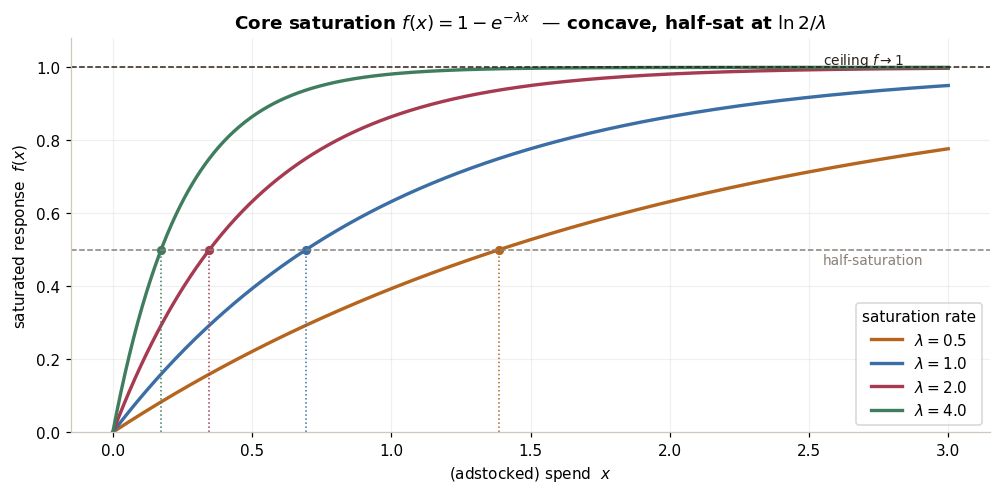

In [3]:
# Logistic/exponential saturation at several lambda, with half-saturation lines marked.
fig, ax = plt.subplots(figsize=(9.2, 4.6))
cols = [CHANNEL_COLORS[k] for k in CH]
for lam, col in zip(LAMS, cols):
    f = logistic_saturation(x, lam)
    ax.plot(x, f, color=col, lw=2.2, label=rf"$\lambda={lam}$")
    xhalf = np.log(2) / lam                      # half-saturation point
    ax.plot([xhalf, xhalf], [0, 0.5], color=col, lw=1.0, ls=":")
    ax.plot(xhalf, 0.5, "o", color=col, ms=5)
ax.axhline(0.5, color=MUTED, lw=1.0, ls="--")
ax.axhline(1.0, color=INK, lw=1.0, ls="--")
ax.text(2.55, 1.01, "ceiling $f\\to 1$", color=INK, fontsize=9)
ax.text(2.55, 0.46, "half-saturation", color=MUTED, fontsize=9)
ax.set_xlabel("(adstocked) spend  $x$")
ax.set_ylabel("saturated response  $f(x)$")
ax.set_title(r"Core saturation $f(x)=1-e^{-\lambda x}$  — concave, half-sat at $\ln 2/\lambda$")
ax.set_ylim(0, 1.08); ax.legend(title="saturation rate", loc="lower right")
plt.tight_layout(); plt.show()

In [4]:
# VERIFY (1): every claim above, including the quantities we plotted.
xpos = np.linspace(1e-4, 6.0, 4000)            # strictly positive grid
xneg = np.linspace(-2.0, -1e-3, 50)            # negative inputs

for lam in LAMS:
    f = logistic_saturation(xpos, lam)
    # (i) matches the source formula EXACTLY: 1 - exp(-lam * clip(x, 0, None)).
    assert np.allclose(f, 1.0 - np.exp(-lam * np.clip(xpos, 0, None)), atol=1e-12)
    # (ii) anchored at the origin.
    assert np.isclose(logistic_saturation(np.array([0.0]), lam)[0], 0.0)
    # (iii) negatives clip to 0 -> f == 0 there.
    assert np.allclose(logistic_saturation(xneg, lam), 0.0)
    # (iv) strictly increasing on x>0 and strictly < 1 (range [0,1)).
    assert np.all(np.diff(f) > 0), f"not strictly increasing at lam={lam}"
    assert np.all(f < 1.0), f"f reached/exceeded 1 at lam={lam}"
    # (v) STRICTLY CONCAVE everywhere -> diffs of the slope are negative (no inflection).
    slope = np.diff(f)
    assert np.all(np.diff(slope) < 0), f"not strictly concave at lam={lam}"
    # (vi) half-saturation point x = ln(2)/lam gives f == 0.5.
    xhalf = np.log(2) / lam
    assert np.isclose(logistic_saturation(np.array([xhalf]), lam)[0], 0.5, atol=1e-9)
print("✓ matches source 1 - exp(-lam*clip(x,0)) ; f(0)=0 ; f(neg)=0")
print("✓ strictly increasing, strictly < 1  (range [0,1))")
print("✓ strictly CONCAVE on x>=0 (no inflection -> not an S-curve)")
print("✓ half-saturation at x = ln2/lam gives f = 0.5 :",
      {lam: round(np.log(2)/lam, 3) for lam in LAMS})

✓ matches source 1 - exp(-lam*clip(x,0)) ; f(0)=0 ; f(neg)=0
✓ strictly increasing, strictly < 1  (range [0,1))
✓ strictly CONCAVE on x>=0 (no inflection -> not an S-curve)
✓ half-saturation at x = ln2/lam gives f = 0.5 : {0.5: np.float64(1.386), 1.0: np.float64(0.693), 2.0: np.float64(0.347), 4.0: np.float64(0.173)}


The dotted droplines land exactly on $x_{1/2}=\ln 2/\lambda$ for each $\lambda$, and the assertion
`np.diff(slope) < 0` is the machine-checked statement that *the curve never stops bending downward* —
the formal version of "this is concave, not an S."

## 2. The alternative: Hill saturation (the *real* S-curve)

The other common family — used in the framework's PyMC / `mmm_extensions` path — is the **Hill**
function (a.k.a. Michaelis–Menten when $n=1$):

$$
f_{\text{Hill}}(x) \;=\; \frac{x^{n}}{x^{n} + \kappa^{n}}, \qquad x \ge 0,\; \kappa > 0,\; n > 0.
$$

It has two interpretable knobs:

- **$\kappa$ (the half-saturation point, "EC50").** Plug in $x=\kappa$:
  $f_{\text{Hill}}(\kappa) = \dfrac{\kappa^n}{\kappa^n + \kappa^n} = \dfrac{\kappa^n}{2\kappa^n} = \tfrac12$.
  So $\kappa$ is, *exactly and for every $n$*, the spend at which the channel hits half its ceiling.
  Unlike the exponential's $\ln2/\lambda$, here the half-sat location is the parameter itself.
- **$n$ (the shape / Hill coefficient).** $n=1$ gives a **hyperbolic**, concave curve (diminishing from
  the first dollar). $n>1$ gives a genuine **S-shape**: a *slow start*, an inflection, then a bend to the
  ceiling. $n<1$ saturates extremely fast.

Like the core curve, $f_{\text{Hill}}(0)=0$ and $f_{\text{Hill}}\to 1$ as $x\to\infty$ (range $[0,1)$).

**The framework anchors $\kappa$ to the data.** Because $\kappa$ is only weakly identified from
observational data (it trades off against adstock decay and $\beta$ — the equifinality theme of notebook
01), `SaturationConfig.compute_kappa_bounds_from_data(x, percentiles=(0.1, 0.9))` reads $\kappa$'s prior
bounds straight off observed-spend percentiles, keeping the curve's elbow inside the region the data
actually cover. (The core `BayesianMMM` uses logistic saturation and does **not** read $\kappa$.)

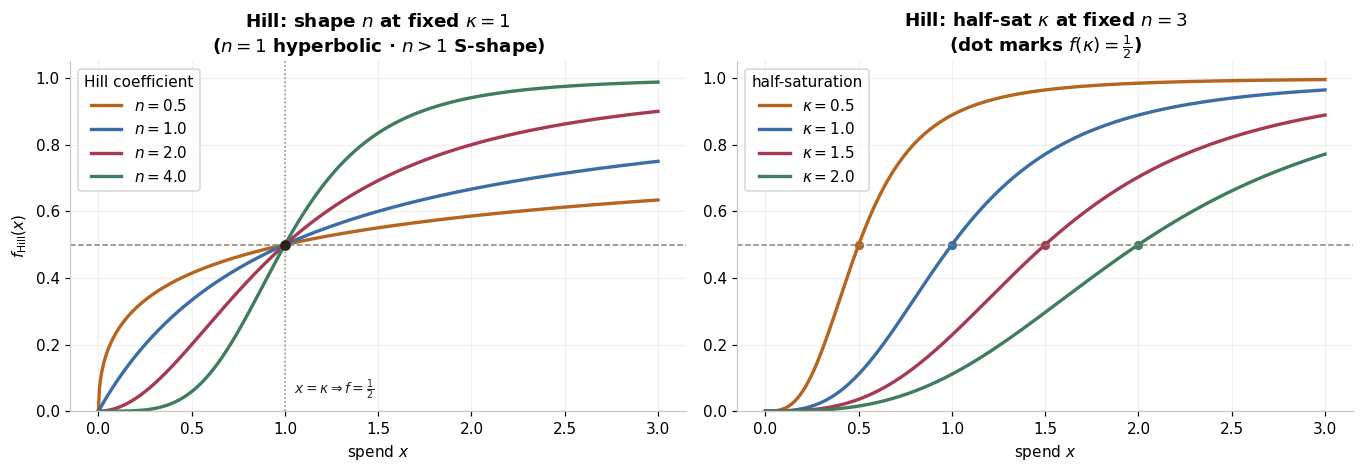

In [5]:
def hill(x, kappa, n):
    '''Hill saturation f(x) = x^n / (x^n + kappa^n), negatives clipped to 0.'''
    xc = np.clip(x, 0, None)
    xn = xc ** n
    return xn / (xn + kappa ** n)

# Sweep (kappa, n): fix kappa, vary n to expose the n=1 -> n>1 shape change;
# and vary kappa at fixed n to show the half-sat point sliding.
fig, (axn, axk) = plt.subplots(1, 2, figsize=(12.5, 4.4))

# Left: vary the shape n at fixed kappa = 1.0.
kappa0 = 1.0
for n, col in zip([0.5, 1.0, 2.0, 4.0], cols):
    f = hill(x, kappa0, n)
    axn.plot(x, f, color=col, lw=2.2, label=rf"$n={n}$")
axn.axvline(kappa0, color=MUTED, lw=1.0, ls=":")
axn.axhline(0.5, color=MUTED, lw=1.0, ls="--")
axn.plot(kappa0, 0.5, "o", color=INK, ms=6)
axn.text(kappa0 + 0.05, 0.05, r"$x=\kappa\Rightarrow f=\frac{1}{2}$", color=INK, fontsize=9)
axn.set_title(r"Hill: shape $n$ at fixed $\kappa=1$" + "\n($n{=}1$ hyperbolic · $n{>}1$ S-shape)")
axn.set_xlabel("spend $x$"); axn.set_ylabel(r"$f_{\mathrm{Hill}}(x)$")
axn.set_ylim(0, 1.05); axn.legend(title="Hill coefficient")

# Right: vary kappa at fixed n = 3 (clear S) -> half-sat point slides to kappa.
n0 = 3.0
for kap, col in zip([0.5, 1.0, 1.5, 2.0], cols):
    f = hill(x, kap, n0)
    axk.plot(x, f, color=col, lw=2.2, label=rf"$\kappa={kap}$")
    axk.plot(kap, 0.5, "o", color=col, ms=5)
axk.axhline(0.5, color=MUTED, lw=1.0, ls="--")
axk.set_title(r"Hill: half-sat $\kappa$ at fixed $n=3$" + "\n(dot marks $f(\\kappa)=\\frac{1}{2}$)")
axk.set_xlabel("spend $x$"); axk.set_ylim(0, 1.05); axk.legend(title="half-saturation")
plt.tight_layout(); plt.show()

In [6]:
# VERIFY (2): Hill identities, including the plotted half-sat dots and the shape claims.
xpos = np.linspace(1e-4, 8.0, 5000)

for kap in [0.5, 1.0, 1.5, 2.0]:
    for n in [0.5, 1.0, 2.0, 3.0, 4.0]:
        f = hill(xpos, kap, n)
        # (i) anchored at 0 and bounded in [0,1).
        assert np.isclose(hill(np.array([0.0]), kap, n)[0], 0.0)
        assert np.all((f >= 0) & (f < 1.0))
        # (ii) f itself is monotone INCREASING for every n>0 (this holds even for S-shapes).
        assert np.all(np.diff(f) >= -1e-12), f"Hill not monotone at kappa={kap}, n={n}"
        # (iii) EXACT half-saturation: f(kappa) == 0.5 for all n (assert exact, not approx).
        assert np.isclose(hill(np.array([kap]), kap, n)[0], 0.5, atol=1e-12)
print("✓ Hill anchored at 0, range [0,1)")
print("✓ Hill f is monotone increasing for every n (incl. S-shapes)")
print("✓ Hill half-saturation is EXACT: f(kappa) = 1/2 for all n")

✓ Hill anchored at 0, range [0,1)
✓ Hill f is monotone increasing for every n (incl. S-shapes)
✓ Hill half-saturation is EXACT: f(kappa) = 1/2 for all n


Note what we did **not** assert: that the Hill *derivative* is monotone. For $n>1$ it is not — the slope
*rises* off zero, peaks at the inflection, then falls. That non-monotone slope is exactly the "slow start"
of an S-curve, and it is the heart of the next section.

## 3. Marginal returns: the value of the next dollar

The slope $f'(x)$ is the **marginal response** — how much extra outcome the *next* unit of spend buys.
Scaled by the coefficient and divided by price it becomes **marginal ROAS** (the basis for budget
optimization: you keep funding a channel while its marginal return beats the alternatives). The two
families tell sharply different marginal stories.

**Core (exponential).** $f'(x) = \lambda e^{-\lambda x}$. This is **maximal at the origin**
($f'(0)=\lambda$) and **strictly decreasing** thereafter — the very first dollar is the most valuable
and every dollar after is worth less. *Always* diminishing, from the start.

**Hill.** Differentiate $f=\frac{x^n}{x^n+\kappa^n}$ with the quotient rule:

$$
f_{\text{Hill}}'(x)
= \frac{n\, x^{\,n-1}\,(x^n+\kappa^n) - x^n\, n\, x^{\,n-1}}{(x^n+\kappa^n)^2}
= \frac{n\,\kappa^{n}\,x^{\,n-1}}{\left(x^{n}+\kappa^{n}\right)^{2}}.
$$

Behaviour at the origin splits on $n$:

- $n<1$: $f'(x)\to\infty$ as $x\to 0^+$ (infinitely steep start, then collapses).
- $n=1$: $f'(0)=1/\kappa$, finite and then strictly decreasing (hyperbolic — like the exponential in
  spirit).
- $n>1$: $f'(0)=0$. The next dollar is worth *almost nothing* at low spend; the marginal curve **rises**
  to a peak at the inflection $x^\star = \kappa\!\left(\frac{n-1}{n+1}\right)^{1/n}$, then falls. This is
  the "you must clear a threshold before the channel works" story.

A clean checkpoint: the slope **at** half-saturation $x=\kappa$ is
$f_{\text{Hill}}'(\kappa) = \dfrac{n\,\kappa^{n}\,\kappa^{\,n-1}}{(2\kappa^{n})^{2}}
= \dfrac{n\,\kappa^{2n-1}}{4\,\kappa^{2n}} = \dfrac{n}{4\kappa}$,
and for the exponential the slope at *its* half-sat is $f'(\ln2/\lambda)=\lambda/2$.

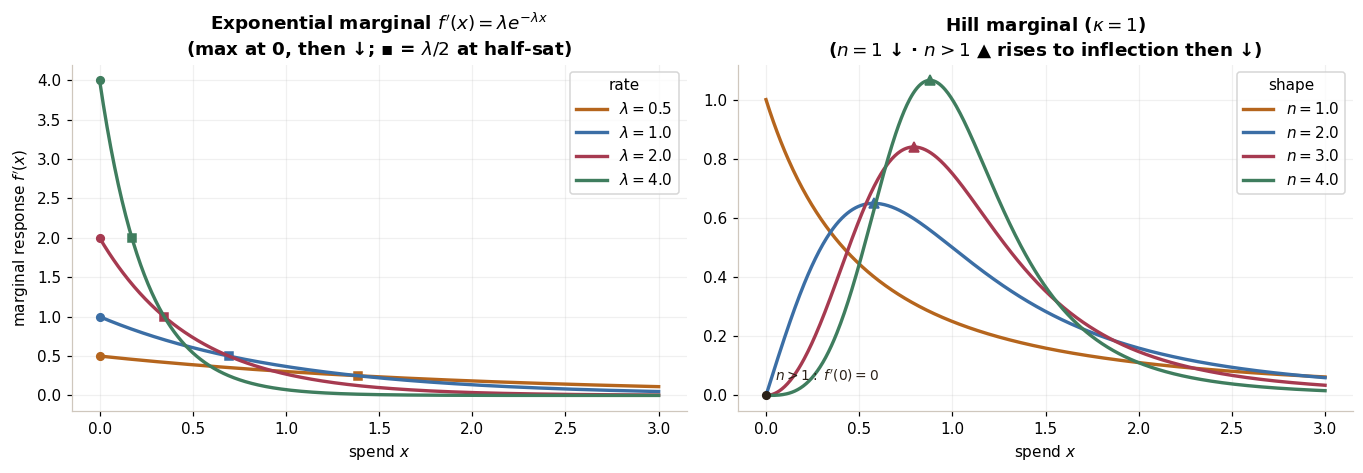

In [7]:
def hill_prime(x, kappa, n):
    '''Analytic Hill derivative n*kappa^n*x^(n-1) / (x^n + kappa^n)^2.'''
    xc = np.clip(x, 1e-12, None)
    return n * kappa ** n * xc ** (n - 1) / (xc ** n + kappa ** n) ** 2

fig, (axe, axh) = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=False)

# Left: exponential marginal — starts highest, only decreases.
for lam, col in zip(LAMS, cols):
    fp = lam * np.exp(-lam * x)
    axe.plot(x, fp, color=col, lw=2.2, label=rf"$\lambda={lam}$")
    axe.plot(0, lam, "o", color=col, ms=5)                 # f'(0) = lambda
    xh = np.log(2) / lam
    axe.plot(xh, lam / 2, "s", color=col, ms=5)            # f'(x_half) = lambda/2
axe.set_title(r"Exponential marginal $f'(x)=\lambda e^{-\lambda x}$" + "\n(max at 0, then ↓; ▪ = $\\lambda/2$ at half-sat)")
axe.set_xlabel("spend $x$"); axe.set_ylabel("marginal response $f'(x)$")
axe.legend(title="rate")

# Right: Hill marginal — n=1 falls; n>1 starts at 0, humps, falls.
kappa0 = 1.0
for n, col in zip([1.0, 2.0, 3.0, 4.0], cols):
    fp = hill_prime(x, kappa0, n)
    axh.plot(x, fp, color=col, lw=2.2, label=rf"$n={n}$")
    if n > 1:
        xstar = kappa0 * ((n - 1) / (n + 1)) ** (1 / n)    # inflection / marginal peak
        axh.plot(xstar, hill_prime(np.array([xstar]), kappa0, n)[0], "^", color=col, ms=6)
axh.plot(0, 0, "o", color=INK, ms=5)
axh.text(0.05, 0.05, r"$n{>}1:\ f'(0)=0$", color=INK, fontsize=9)
axh.set_title(r"Hill marginal ($\kappa=1$)" + "\n($n{=}1$ ↓ · $n{>}1$ ▲ rises to inflection then ↓)")
axh.set_xlabel("spend $x$"); axh.legend(title="shape")
plt.tight_layout(); plt.show()

In [8]:
# VERIFY (3): analytic derivatives match finite differences, and the marginal-shape claims.
xc = np.linspace(1e-3, 5.0, 6000)
dx = xc[1] - xc[0]

# (a) Exponential: analytic f' vs central difference of logistic_saturation.
for lam in LAMS:
    f = logistic_saturation(xc, lam)
    fd = np.gradient(f, dx)                       # numerical slope
    an = lam * np.exp(-lam * xc)                  # analytic slope
    assert np.allclose(fd[2:-2], an[2:-2], rtol=2e-3, atol=2e-3), f"exp deriv mismatch lam={lam}"
    assert np.all(np.diff(an) < 0)                # strictly DECREASING -> always diminishing
    assert np.isclose(lam * np.exp(-lam * np.log(2) / lam), lam / 2)   # f'(x_half) = lam/2

# (b) Hill: analytic f' vs central difference of hill(); plus the n-split at the origin.
for n in [1.0, 2.0, 3.0, 4.0]:
    f = hill(xc, 1.0, n)
    fd = np.gradient(f, dx)
    an = hill_prime(xc, 1.0, n)
    assert np.allclose(fd[3:-3], an[3:-3], rtol=3e-3, atol=3e-3), f"Hill deriv mismatch n={n}"
    if n > 1:
        # f'(0) = 0 for n>1 (slow start) -> NOT monotone: it rises before it falls.
        assert hill_prime(np.array([1e-6]), 1.0, n)[0] < 1e-3
        assert np.any(np.diff(an) > 0), f"Hill n={n} marginal should rise somewhere"
        xstar = 1.0 * ((n - 1) / (n + 1)) ** (1 / n)
        assert abs(xc[np.argmax(an)] - xstar) < 5e-2     # peak at predicted inflection
assert hill_prime(np.array([1.0]), 1.0, 3.0)[0] == 3.0 / (4 * 1.0)   # f'(kappa)=n/(4 kappa)
print("✓ exponential f' matches finite differences ; strictly decreasing ; f'(x_half)=lam/2")
print("✓ Hill f' matches finite differences")
print("✓ Hill n>1: f'(0)=0, marginal RISES then falls (non-monotone), peak at the inflection")
print("✓ Hill f'(kappa) = n/(4 kappa) exactly")

✓ exponential f' matches finite differences ; strictly decreasing ; f'(x_half)=lam/2
✓ Hill f' matches finite differences
✓ Hill n>1: f'(0)=0, marginal RISES then falls (non-monotone), peak at the inflection
✓ Hill f'(kappa) = n/(4 kappa) exactly


The left panel is "every dollar worth less than the last." The right panel for $n>1$ is "the first
dollars are nearly wasted, returns *grow* until you clear the inflection, then diminish" — a qualitatively
different optimization problem (small budgets can be worse than none). Picking the saturation family is
therefore a real modeling decision, not a cosmetic one.

## 4. Why normalize the input before saturating

$\lambda$ is a **rate with units of 1/spend**: the product $\lambda x$ in $e^{-\lambda x}$ must be
dimensionless. If channel A spends in the thousands and channel B in the millions, the *same* numeric
$\lambda$ means completely different saturation behaviour — and a shared prior on $\lambda$ would be
incoherent across channels. The fix is to **normalize** each channel's (adstocked) spend to a common
scale, e.g. divide by its own maximum so $x\in[0,1]$. Then:

- $\lambda$ is **comparable across channels**: it measures saturation *relative to that channel's own
  observed range*, so one prior fits all.
- The half-saturation point $x_{1/2}=\ln2/\lambda$ lands at a *fraction of the channel's max spend* — an
  interpretable quantity ("this channel half-saturates at 35% of its peak weekly spend").

This is why the prior $\lambda\sim\mathrm{Exponential}(0.5)$ (mean $2$) is sensible **only** on normalized
input: at $\lambda=2$ on $x\in[0,1]$, the elbow $x_{1/2}=\ln2/2\approx0.35$ sits comfortably *inside* the
observed range, where the data can actually inform the curve. On raw spend it would be nonsense.

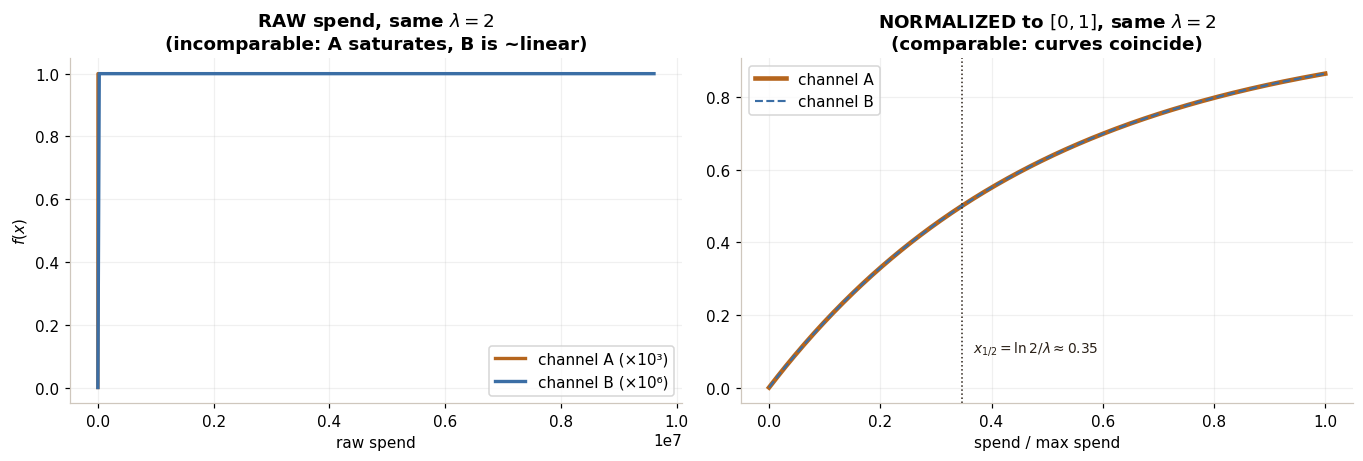

In [9]:
# Same lambda, two channels with wildly different raw scales -> normalization makes lambda comparable.
rng = np.random.default_rng(3)
raw_A = rng.gamma(3.0, 1.5e3, size=300)      # channel A: spend in thousands
raw_B = rng.gamma(3.0, 8.0e5, size=300)      # channel B: spend in (near) millions
lam = 2.0

fig, (axraw, axnorm) = plt.subplots(1, 2, figsize=(12.5, 4.3))

# Raw scale: identical lambda saturates A instantly but barely touches B.
gridA = np.linspace(0, raw_A.max(), 400)
gridB = np.linspace(0, raw_B.max(), 400)
axraw.plot(gridA, logistic_saturation(gridA, lam), color=CHANNEL_COLORS[CH[0]], lw=2.2, label="channel A (×10³)")
axraw.plot(gridB, logistic_saturation(gridB, lam), color=CHANNEL_COLORS[CH[1]], lw=2.2, label="channel B (×10⁶)")
axraw.set_title(r"RAW spend, same $\lambda=2$" + "\n(incomparable: A saturates, B is ~linear)")
axraw.set_xlabel("raw spend"); axraw.set_ylabel(r"$f(x)$"); axraw.legend()

# Normalized to [0,1] by each channel's own max: the curve is now identical and interpretable.
nA = gridA / raw_A.max()
nB = gridB / raw_B.max()
axnorm.plot(nA, logistic_saturation(nA, lam), color=CHANNEL_COLORS[CH[0]], lw=3.0, label="channel A")
axnorm.plot(nB, logistic_saturation(nB, lam), color=CHANNEL_COLORS[CH[1]], lw=1.4, ls="--", label="channel B")
xh = np.log(2) / lam
axnorm.axvline(xh, color=INK, lw=1.0, ls=":")
axnorm.text(xh + 0.02, 0.1, rf"$x_{{1/2}}=\ln2/\lambda\approx{xh:.2f}$", color=INK, fontsize=9)
axnorm.set_title(r"NORMALIZED to $[0,1]$, same $\lambda=2$" + "\n(comparable: curves coincide)")
axnorm.set_xlabel("spend / max spend"); axnorm.legend()
plt.tight_layout(); plt.show()

In [10]:
# VERIFY (4): after per-channel max-normalization, the SAME lambda gives the SAME curve, and the
# half-sat point is a fixed fraction of max spend.
lam = 2.0
fracs = np.linspace(0, 1, 200)                 # fraction-of-max grid, shared across channels
curveA = logistic_saturation(fracs, lam)
curveB = logistic_saturation(fracs, lam)
assert np.allclose(curveA, curveB)             # identical once normalized -> lambda comparable
xh = np.log(2) / lam
assert np.isclose(logistic_saturation(np.array([xh]), lam)[0], 0.5)
assert 0.0 < xh < 1.0                          # elbow lands INSIDE the [0,1] observed range
print(f"✓ normalized input: identical lambda -> identical curve (lambda is comparable)")
print(f"✓ half-sat lands at {xh:.3f} of max spend -- inside [0,1], where data inform the curve")

✓ normalized input: identical lambda -> identical curve (lambda is comparable)
✓ half-sat lands at 0.347 of max spend -- inside [0,1], where data inform the curve


## 5. Saturation $\times$ coefficient: the contribution ceiling

A channel's contribution to the outcome is the saturated response scaled by its **coefficient** $\beta$
(`model/base.py`: `channel_contrib = beta * x_saturated`):

$$
\text{contribution}(x) \;=\; \beta \cdot f\big(\text{adstock}(x)\big).
$$

Two consequences fall straight out of $f\in[0,1)$:

1. **$\beta$ is a vertical scale.** It stretches the whole curve; the *shape* (where the elbow is, how
   fast it bends) is owned entirely by $\lambda$ (or $\kappa,n$). Timing/shape and size are cleanly
   separated — which is also *why* they can trade off against adstock (the identifiability theme of
   notebook 01).
2. **A hard ceiling near $\beta$.** Since $f(x)<1$ strictly and $f\to1$, the contribution satisfies
   $\beta f(x) < \beta$ for all finite $x$ and $\to\beta$ as $x\to\infty$. So $\beta$ **is** the channel's
   maximum achievable contribution — the most outcome you could ever buy from it, at any budget. That cap
   is what makes "throw money at the best channel" a bounded, not unbounded, strategy.

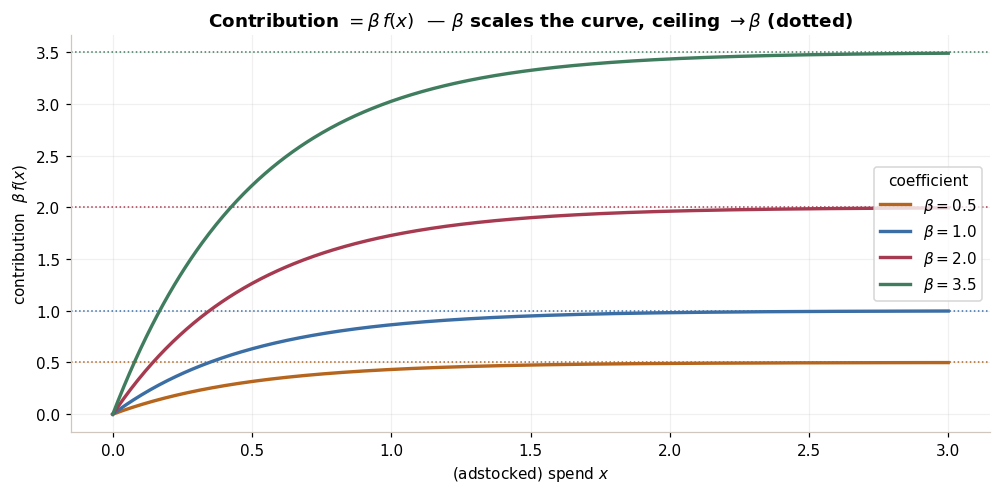

In [11]:
# beta scales the same saturation curve; the ceiling sits at beta.
lam = 2.0
f = logistic_saturation(x, lam)
betas = [0.5, 1.0, 2.0, 3.5]

fig, ax = plt.subplots(figsize=(9.2, 4.6))
for b, col in zip(betas, cols):
    ax.plot(x, b * f, color=col, lw=2.2, label=rf"$\beta={b}$")
    ax.axhline(b, color=col, lw=1.0, ls=":")            # ceiling = beta
ax.set_xlabel("(adstocked) spend $x$")
ax.set_ylabel(r"contribution  $\beta\,f(x)$")
ax.set_title(r"Contribution $=\beta\,f(x)$  — $\beta$ scales the curve, ceiling $\to\beta$ (dotted)")
ax.legend(title="coefficient", loc="center right")
plt.tight_layout(); plt.show()

In [12]:
# VERIFY (5): the contribution ceiling is beta (strictly below, approached at large x).
lam = 2.0
for b in betas:
    contrib = b * logistic_saturation(x, lam)
    assert np.all(contrib < b)                                   # strictly below the ceiling on the grid
    # Approaches beta from below: at moderate x the gap is tiny but still strictly positive;
    # far enough out the float64 representation saturates exactly to beta (exp underflows).
    mid = b * logistic_saturation(np.array([8.0]), lam)[0]
    assert mid < b and np.isclose(mid, b, atol=1e-6)             # close to, but below, beta
    far = b * logistic_saturation(np.array([50.0]), lam)[0]
    assert np.isclose(far, b, atol=1e-12)                        # numerically pinned at beta
    # beta is a pure vertical scale: contribution / beta is the SAME shape for every beta.
    assert np.allclose(contrib / b, logistic_saturation(x, lam))
print("✓ contribution beta*f(x) < beta for all finite x  (strict ceiling)")
print("✓ contribution -> beta as x grows large (max achievable effect = beta)")
print("✓ beta is a pure vertical scale: contribution/beta is lambda's shape, independent of beta")

✓ contribution beta*f(x) < beta for all finite x  (strict ceiling)
✓ contribution -> beta as x grows large (max achievable effect = beta)
✓ beta is a pure vertical scale: contribution/beta is lambda's shape, independent of beta


## 6. End to end: $\text{spend} \to \text{adstock} \to \text{saturation} \to {}\times\beta$

Now we compose the whole single-channel media response exactly as the model does, in order:

$$
\underbrace{x_t}_{\text{spend}}
\;\xrightarrow{\;\text{adstock}\;}\;
\underbrace{a_t = \sum_{k\ge0}\alpha^k x_{t-k}}_{\text{carryover (nb 01)}}
\;\xrightarrow{\;\text{saturation}\;}\;
\underbrace{f(a_t) = 1 - e^{-\lambda a_t}}_{\text{diminishing returns}}
\;\xrightarrow{\;\times\,\beta\;}\;
\underbrace{\beta\, f(a_t)}_{\text{contribution}_t}.
$$

We use the framework's real `geometric_adstock` for the first stage. **Heads-up on magnitude** (from
notebook 01): `geometric_adstock` returns the *un-normalized* IIR recurrence whose impulse weights sum to
$1/(1-\alpha)>1$, so it *amplifies* the level of the series before saturation sees it. We feed that
amplified series straight into $f$, exactly as the composition above specifies, and we assert the level
relationship so the magnitude story is explicit rather than hand-waved.

Two charts: (1) the time series at each stage on a bursty spend plan, and (2) the **static response
curve** — contribution as a function of a *steady* per-period spend level, which is the object a planner
reads to choose a budget.

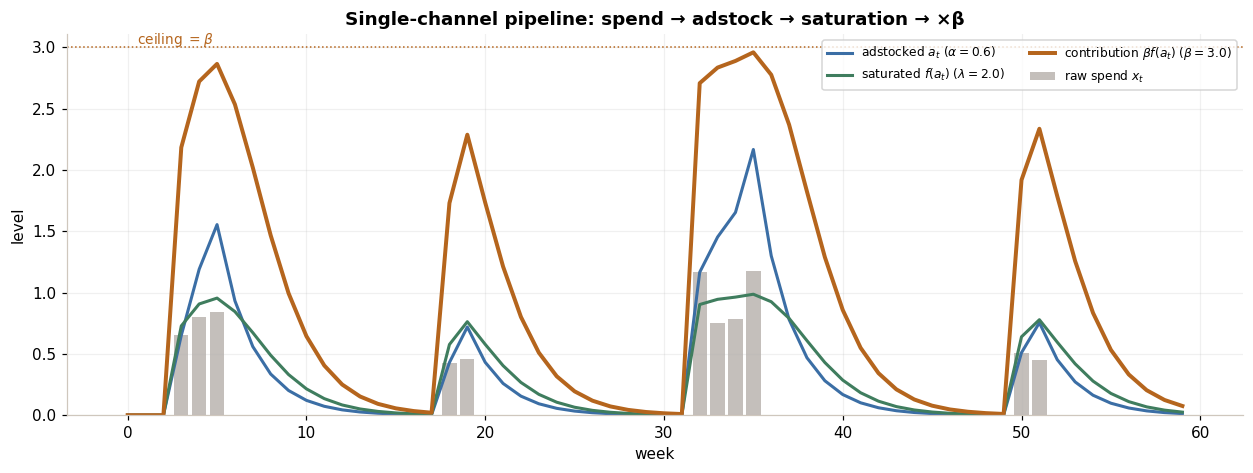

In [13]:
# (1) Stage-by-stage on a bursty weekly spend plan.
rng = np.random.default_rng(11)
T = 60
spend = np.zeros(T)
for start, length, level in [(3, 3, 1.0), (18, 2, 0.7), (32, 4, 1.2), (50, 2, 0.6)]:
    spend[start:start + length] = level * (0.6 + 0.4 * rng.random(length))

alpha, lam, beta = 0.6, 2.0, 3.0
adstocked = geometric_adstock(spend, alpha)            # stage 1 (un-normalized recurrence)
saturated = logistic_saturation(adstocked, lam)        # stage 2
contribution = beta * saturated                        # stage 3

fig, ax = plt.subplots(figsize=(11.5, 4.4))
wk = np.arange(T)
ax.bar(wk, spend, color=MUTED, alpha=0.5, label="raw spend $x_t$")
ax.plot(wk, adstocked, color=PALETTE["sky"], lw=2.0, label=rf"adstocked $a_t$ ($\alpha={alpha}$)")
ax.plot(wk, saturated, color=PALETTE["leaf"], lw=2.0, label=rf"saturated $f(a_t)$ ($\lambda={lam}$)")
ax.plot(wk, contribution, color=ACCENT, lw=2.6, label=rf"contribution $\beta f(a_t)$ ($\beta={beta}$)")
ax.axhline(beta, color=ACCENT, lw=1.0, ls=":")
ax.text(0.5, beta + 0.03, r"ceiling $=\beta$", color=ACCENT, fontsize=9)
ax.set_xlabel("week"); ax.set_ylabel("level")
ax.set_title("Single-channel pipeline: spend → adstock → saturation → ×β")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

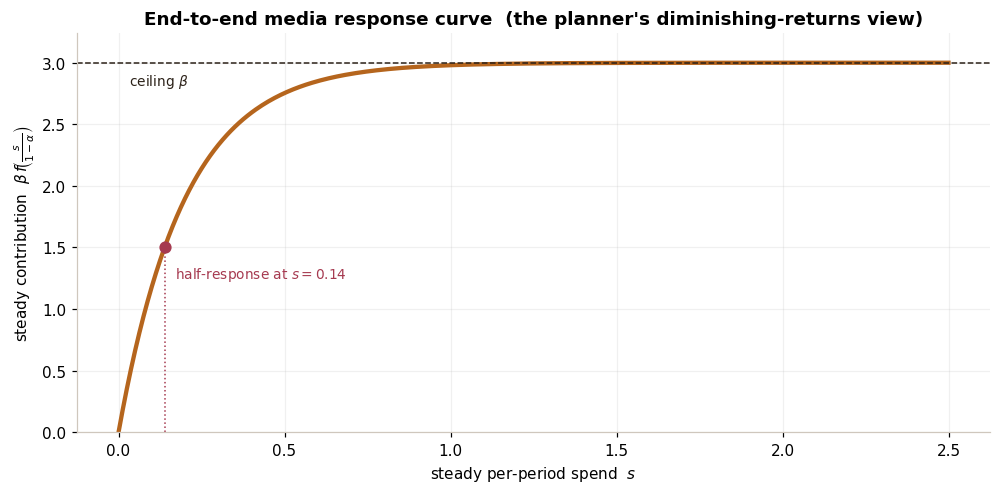

In [14]:
# (2) Static response curve: steady per-period spend -> steady-state contribution.
# At a constant spend level s, the geometric adstock settles to s/(1-alpha); push that
# steady level through saturation x beta to get the response curve a planner reads.
levels = np.linspace(0, 2.5, 400)
steady_adstock = levels / (1 - alpha)                  # geometric steady state, sum_k alpha^k * s
response = beta * logistic_saturation(steady_adstock, lam)

fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(levels, response, color=ACCENT, lw=2.8)
ax.axhline(beta, color=INK, lw=1.0, ls="--"); ax.text(0.03, beta - 0.18, r"ceiling $\beta$", color=INK, fontsize=9)
# Mark the half-contribution spend level (where beta*f = beta/2 i.e. f = 1/2).
s_half = (1 - alpha) * np.log(2) / lam                 # invert: steady_adstock = ln2/lam
ax.plot(s_half, beta / 2, "o", color=PALETTE["berry"], ms=7)
ax.plot([s_half, s_half], [0, beta / 2], color=PALETTE["berry"], lw=1.0, ls=":")
ax.text(s_half + 0.03, beta / 2 - 0.25, rf"half-response at $s={s_half:.2f}$", color=PALETTE["berry"], fontsize=9)
ax.set_xlabel("steady per-period spend  $s$")
ax.set_ylabel(r"steady contribution  $\beta\,f\!\left(\frac{s}{1-\alpha}\right)$")
ax.set_title("End-to-end media response curve  (the planner's diminishing-returns view)")
ax.set_ylim(0, beta * 1.08)
plt.tight_layout(); plt.show()

In [15]:
# VERIFY (6): the composed pipeline behaves as derived.
alpha, lam, beta = 0.6, 2.0, 3.0

# (i) order of composition is exactly beta * f(adstock(spend)).
adstocked = geometric_adstock(spend, alpha)
recompose = beta * logistic_saturation(adstocked, lam)
assert np.allclose(recompose, contribution)

# (ii) adstock AMPLIFIES the level: a steady input s settles to s/(1-alpha) > s (un-normalized kernel).
s = 1.0
steady = geometric_adstock(np.full(400, s), alpha)[-1]      # converged steady state
assert np.isclose(steady, s / (1 - alpha), atol=1e-6)
assert steady > s

# (iii) the whole pipeline is bounded by beta (saturation caps it no matter the spend).
assert np.all(contribution < beta)
assert np.all(response < beta)

# (iv) the marked half-response spend level really yields beta/2.
s_half = (1 - alpha) * np.log(2) / lam
val = beta * logistic_saturation(np.array([s_half / (1 - alpha)]), lam)[0]
assert np.isclose(val, beta / 2, atol=1e-9)

# (v) response curve is monotone increasing and concave in the steady spend level.
assert np.all(np.diff(response) >= -1e-12)
assert np.all(np.diff(np.diff(response[1:])) < 1e-9)        # concave (slopes non-increasing)
print("✓ pipeline == beta * f(adstock(spend))  (composition order)")
print(f"✓ steady adstock = s/(1-alpha) = {s/(1-alpha):.2f}  (un-normalized kernel amplifies level)")
print("✓ contribution and response curve are bounded above by beta")
print(f"✓ half-response at steady spend s = {s_half:.3f}  ->  beta/2")
print("✓ end-to-end response curve is monotone increasing and concave")

✓ pipeline == beta * f(adstock(spend))  (composition order)
✓ steady adstock = s/(1-alpha) = 2.50  (un-normalized kernel amplifies level)
✓ contribution and response curve are bounded above by beta
✓ half-response at steady spend s = 0.139  ->  beta/2
✓ end-to-end response curve is monotone increasing and concave


## Recap & what's next

**The two saturation families, side by side:**

| | $f(x)$ | $f'(x)$ | Half-sat | Shape on $x\ge0$ | Marginal at $x=0$ |
|---|---|---|---|---|---|
| Core (exp) | $1-e^{-\lambda x}$ | $\lambda e^{-\lambda x}$ | $\ln2/\lambda$ | strictly **concave** | $\lambda$ (max, then ↓) |
| Hill, $n=1$ | $\frac{x}{x+\kappa}$ | $\frac{\kappa}{(x+\kappa)^2}$ | $\kappa$ | concave (hyperbolic) | $1/\kappa$ (then ↓) |
| Hill, $n>1$ | $\frac{x^n}{x^n+\kappa^n}$ | $\frac{n\kappa^n x^{n-1}}{(x^n+\kappa^n)^2}$ | $\kappa$ | **S-shape** (inflection) | $0$ (rises, then ↓) |

**The things people get wrong:**
1. The core curve $1-e^{-\lambda x}$ is **concave, not S-shaped** (the framework docstring's "S-shaped" is a
   misnomer we corrected and `assert`ed). The genuine S belongs to **Hill with $n>1$**, whose marginal
   return *starts at zero* and humps before diminishing.
2. **Normalize the input** before saturating, so $\lambda$ is comparable across channels and the prior
   $\lambda\sim\mathrm{Exponential}(0.5)$ places the elbow inside the observed range.
3. With $f\in[0,1)$, contribution $\beta f$ has a **hard ceiling at $\beta$** — the channel's maximum
   achievable effect, and the reason an optimal budget is finite.

**Where this sits in the series:**
- **`math_01_adstock.ipynb`** — carryover: the transform that feeds the *input* of saturation, and which
  fights it for identifiability (long-carryover + weak-saturation ≈ short-carryover + strong-saturation).
- **`math_05_calibration.ipynb`** — experiment-calibrated priors pin $\beta$ (the ceiling) with randomized
  lift evidence, which is the cleanest way to break the adstock/saturation/$\beta$ trade-off.